# Task F: Review Sentiment Analysis (NLP)

**Goal:** read a customer's written review and tell whether it is **Negative**, **Neutral** or **Positive**.

**Method (in simple words):**
1. Make a label from the rating: 1-2 = Negative, 3 = Neutral, 4-5 = Positive.
2. Clean the text (small letters, remove extra symbols).
3. Turn the text into numbers with **TF-IDF** (a computer understands only numbers).
4. Train a **Logistic Regression** model.
5. Measure it with accuracy, precision, recall and F1.

## Step 1: Libraries and the reviews table

In [1]:
import sqlite3
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)

conn = sqlite3.connect("ecommerce_hackathon.db")
reviews = pd.read_sql_query("select * from reviews", conn)
print(reviews.shape)
reviews.head()

(26000, 6)


,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Recommended for others."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurate. Good value for money. product bilkul theek nikla"
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good value for money."
3,4,2735,90,2026-03-25,4,"Product arrived in great condition, quality feels premium. Happy with the purchase."
4,5,2124,197,2026-02-23,4,"Good experience overall, packing was neat. Will order again."


## Step 2: Handle the unusable reviews

In Task A we saw:
- **Empty or missing text** (90 reviews): without text the model cannot learn anything, so we drop them.
- **Rating 0 or 6** (25 reviews): the rating scale is 1 to 5, so these are wrong and no label can be made, so we drop them.

(The 16 reviews with an invalid *date* are kept, because the sentiment model does not use the date.)

In [2]:
reviews_clean = reviews.copy()
before = len(reviews_clean)

reviews_clean["review_text"] = reviews_clean["review_text"].fillna("").str.strip()
reviews_clean = reviews_clean[reviews_clean["review_text"] != ""]
reviews_clean = reviews_clean[reviews_clean["rating"].between(1, 5)]

print("Before:", before, "| After:", len(reviews_clean), "| Removed:", before - len(reviews_clean))

Before: 26000 | After: 25885 | Removed: 115


## Step 3: Create the sentiment labels

| Rating | Label |
|---|---|
| 1, 2 | Negative |
| 3 | Neutral |
| 4, 5 | Positive |

`map(...)` gives every rating its label.

In [3]:
def make_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

reviews_clean["sentiment"] = reviews_clean["rating"].map(make_label)

print(reviews_clean["sentiment"].value_counts())
print()
print(reviews_clean["sentiment"].value_counts(normalize=True).round(3))

sentiment
Positive    18421
Neutral      5458
Negative     2006
Name: count, dtype: int64

sentiment
Positive    0.712
Neutral     0.211
Negative    0.077
Name: proportion, dtype: float64


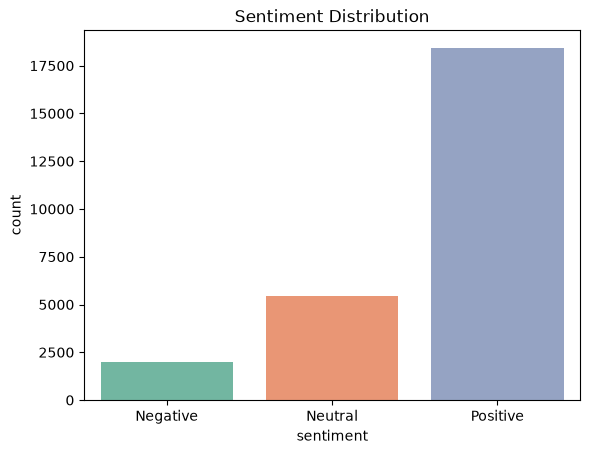

In [4]:
sns.countplot(data=reviews_clean, x="sentiment", order=["Negative", "Neutral", "Positive"], palette="Set2")
plt.title("Sentiment Distribution")
plt.show()

**Observation:** There are a lot of Positive reviews (about 71%), about 21% Neutral and only about 8% Negative. The data is **imbalanced**: a model that always says "Positive" would already look very accurate. That is why we do not trust accuracy alone and also look at precision, recall and F1.

## Step 4: Clean the text (text preparation)

We write a small function that:
1. Makes all letters **lowercase** ("Good" and "good" become the same)
2. **Removes** everything except letters (symbols, numbers)
3. Removes extra spaces

`re.sub(...)` finds a pattern in the text and replaces it. We do **not** remove stop words (the, is, a), because small words like "not" can flip the meaning ("not good").

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)      # remove everything except letters and spaces
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

reviews_clean["clean_text"] = reviews_clean["review_text"].apply(clean_text)

print(reviews_clean[["review_text", "clean_text"]].head(3).to_string())

                                                                                         review_text                                                                                      clean_text
0                                I would buy this again, item feels durable. Recommended for others.                                i would buy this again item feels durable recommended for others
1  Very satisfied, seller description was accurate. Good value for money. product bilkul theek nikla  very satisfied seller description was accurate good value for money product bilkul theek nikla
2                                       Very satisfied, quality feels premium. Good value for money.                                       very satisfied quality feels premium good value for money


## Step 5: Repeated sentences (avoiding leakage)

In Task A we saw that many review sentences are repeated exactly. Let us see how many **different (unique)** sentences there are:

In [6]:
print("Total reviews           :", len(reviews_clean))
print("Unique sentences        :", reviews_clean["clean_text"].nunique())

# does any sentence appear with two different sentiments? (conflict)
conflict = reviews_clean.groupby("clean_text")["sentiment"].nunique()
print("Sentences with 2+ labels:", (conflict > 1).sum())

Total reviews           : 25885
Unique sentences        : 4484
Sentences with 2+ labels: 0


**What is the problem?** If the same sentence is in both the train and the test set, the model can **memorise** it and the test score can be **fake (too high)** (**data leakage**). We saw that no sentence appears with two different labels, so removing the repeated sentences is safe.

**Our decision:**
- Leave `reviews_clean` as it is.
- For **training the model** we use only the unique sentences (`drop_duplicates`).
- Below we also compare both ways (with and without the repeated sentences) so that the difference is clear.

In [7]:
reviews_model = reviews_clean.drop_duplicates(subset="clean_text").copy()

print("Reviews used for training:", len(reviews_model))
print(reviews_model["sentiment"].value_counts())

Reviews used for training: 4484
sentiment
Positive    2160
Neutral     1387
Negative     937
Name: count, dtype: int64


## Step 6: Train-Test Split

80% train, 20% test. `stratify` keeps the ratio of the three sentiments the same in both parts.

In [8]:
X = reviews_model["clean_text"]
y = reviews_model["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", len(X_train), "| Test:", len(X_test))

Train: 3587 | Test: 897


## Step 7: TF-IDF + Logistic Regression

**TF-IDF** (Term Frequency - Inverse Document Frequency) gives every word a number: a word that is common in this review but rare in the other reviews gets a higher number. Example: "terrible" is special to a negative review, while "the" is everywhere (low number).

- `ngram_range=(1, 2)`: look at single words ("good") and pairs of words ("not good").
- `min_df=2`: ignore words that appear in only 1 review.
- `class_weight="balanced"`: give more importance to the smaller classes (Negative), so that the model does not just keep saying "Positive".

TF-IDF and the model are in one Pipeline, so saving and loading are easy.

In [9]:
sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

sentiment_model.fit(X_train, y_train)
y_pred = sentiment_model.predict(X_test)
print("Training finished")

Training finished


## Step 8: Evaluation (Accuracy, Precision, Recall, F1)

- **Accuracy:** out of 100 reviews, how many were predicted correctly.
- **Precision:** when the model said "Negative", how often it was right (for each class).
- **Recall:** out of the real Negative reviews, how many the model caught.
- **F1:** the balance between precision and recall.
- **Macro average:** the plain average of the three classes (every class counts equally).

In [10]:
print("Accuracy         :", round(accuracy_score(y_test, y_pred), 3))
print("Precision (macro):", round(precision_score(y_test, y_pred, average="macro"), 3))
print("Recall (macro)   :", round(recall_score(y_test, y_pred, average="macro"), 3))
print("F1 (macro)       :", round(f1_score(y_test, y_pred, average="macro"), 3))
print()
print(classification_report(y_test, y_pred))

Accuracy         : 1.0
Precision (macro): 1.0
Recall (macro)   : 1.0
F1 (macro)       : 1.0

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       187
     Neutral       1.00      1.00      1.00       278
    Positive       1.00      1.00      1.00       432

    accuracy                           1.00       897
   macro avg       1.00      1.00      1.00       897
weighted avg       1.00      1.00      1.00       897



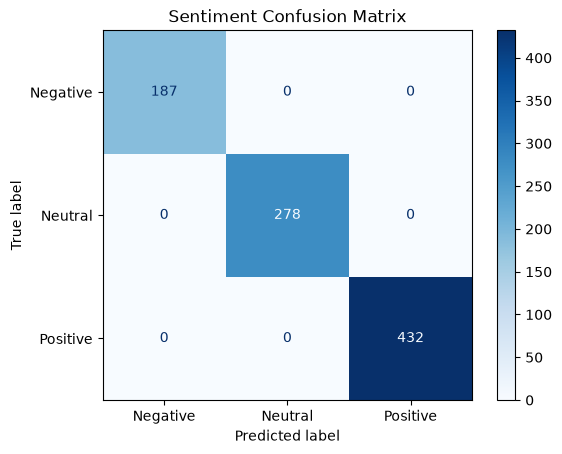

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["Negative", "Neutral", "Positive"], cmap="Blues")
plt.title("Sentiment Confusion Matrix")
plt.show()

**Observation:** Even after removing the repeated sentences the model reaches about **100%** accuracy, precision, recall and F1. This is a very good result, and **such a result is usually suspicious.** We look at the reason below.

### What did the model learn? (the strongest words for every sentiment)

Logistic Regression gives every word a **weight (coefficient)**. The words with the biggest weight for a class are the strongest clues for that class.

In [12]:
tfidf = sentiment_model.named_steps["tfidf"]
lr = sentiment_model.named_steps["model"]
words = np.array(tfidf.get_feature_names_out())

for i, label in enumerate(lr.classes_):
    top_words = words[np.argsort(lr.coef_[i])[-8:][::-1]]        # the 8 words with the biggest weights
    print(label, "->", list(top_words))

Negative -> ['not', 'would not', 'very', 'not recommended', 'bad experience', 'feels cheap', 'cheap', 'unhappy with']
Neutral -> ['average', 'okay', 'acceptable', 'the price', 'could be', 'could', 'be', 'product is']
Positive -> ['good', 'with', 'happy', 'happy with', 'time', 'money', 'value', 'satisfied']


**Observation (why the score is 100%):** The strongest words of every sentiment are very clear (for Negative: "not", "not recommended", "bad experience", "cheap", "unhappy with"; for Neutral: "average", "okay", "acceptable"; for Positive: "good", "happy", "value", "satisfied"). When we looked at the data, the reviews seem to be **generated from templates**:
- every review has only **2 or 3 sentences**,
- there are only 300 different first sentences and 36 different last sentences,
- **every sentence belongs to only one sentiment** (no sentence appeared with two different labels).

So the task is very easy for the model: it basically "recognises the template". It does not mean that it will work as well on real-world reviews.

## Step 9: The effect of repeated sentences (proof of the leakage risk)

Now we train the same model **with the repeated sentences** (the whole `reviews_clean`) and see how much higher the score becomes. If the score is much higher, it is fake, because the same sentences can be in both the train and the test set.

In [13]:
X_all = reviews_clean["clean_text"]
y_all = reviews_clean["sentiment"]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)

leaky_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
leaky_model.fit(Xa_train, ya_train)
ya_pred = leaky_model.predict(Xa_test)

overlap = Xa_test.isin(set(Xa_train)).mean() * 100
print("Percent of test sentences that are also in the train set:", round(overlap, 1), "%")
print()
compare = pd.DataFrame({
    "Setup": ["Unique sentences (our model)", "With repeated sentences"],
    "Accuracy": [round(accuracy_score(y_test, y_pred), 3), round(accuracy_score(ya_test, ya_pred), 3)],
    "F1 (macro)": [round(f1_score(y_test, y_pred, average="macro"), 3), round(f1_score(ya_test, ya_pred, average="macro"), 3)],
})
compare

Percent of test sentences that are also in the train set: 91.6 %



,Setup,Accuracy,F1 (macro)
0,Unique sentences (our model),1.0,1.0
1,With repeated sentences,1.0,1.0


**Observation:** The score with the repeated sentences is about the same (100%), so removing exact duplicates did not change the score. About **92%** of the test sentences were also in the train set, but because the score stayed 100% even after removing them, the real reason is not only the duplicate sentences but **the template-like nature of the data.**

**Lesson:** we removed the repeated sentences before training so that no score would be fake, and we honestly report that the score on this data is very high.

## Step 9b: Overfitting / Underfitting check

We compare the train score and the test score, and we also run **5-fold cross validation** on the train data (the data is split into 5 parts and the test is done 5 times).

In [14]:
from sklearn.model_selection import cross_val_score

train_acc = accuracy_score(y_train, sentiment_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
cv_f1 = cross_val_score(sentiment_model, X_train, y_train, cv=5, scoring="f1_macro")

print("Train accuracy :", round(train_acc, 3))
print("Test accuracy  :", round(test_acc, 3))
print("5-fold CV F1   :", cv_f1.round(3), "| average:", round(cv_f1.mean(), 3))

Train accuracy : 1.0
Test accuracy  : 1.0
5-fold CV F1   : [1. 1. 1. 1. 1.] | average: 1.0


**Result:** Train, test and cross validation are all about **100%**, so there is **no gap** between train and test. That is not the classic sign of overfitting (good train, bad test), and it is not underfitting either. But it is **not normal** for all three to be 100%. It proves that **the data itself is very easy** (the reviews are made from templates, and every sentence has one sentiment), so the model basically "recognised the template". So we cannot claim that the model will work equally well on real-world reviews. This is the biggest limitation of this notebook.

## Step 10: Save the model and test it on new reviews

`sentiment_model` contains both TF-IDF and Logistic Regression. Note: before giving text to the model we must clean it with `clean_text`, exactly as in training.

In [15]:
joblib.dump(sentiment_model, "sentiment_model.pkl")
print("Saved: sentiment_model.pkl")

Saved: sentiment_model.pkl


In [16]:
loaded = joblib.load("sentiment_model.pkl")

samples = [
    "Very disappointed, item stopped working quickly. Would not buy again.",
    "Product is okay, quality matches the price. Not bad, not great.",
    "Excellent quality, highly recommended. Very happy with the purchase!",
    "product bilkul theek nikla, bohat acha",
]

for text in samples:
    pred = loaded.predict([clean_text(text)])[0]
    probs = loaded.predict_proba([clean_text(text)])[0]
    print(pred, "(" + str(round(probs.max() * 100)) + "%) <-", text)

Negative (97%) <- Very disappointed, item stopped working quickly. Would not buy again.
Neutral (97%) <- Product is okay, quality matches the price. Not bad, not great.
Positive (97%) <- Excellent quality, highly recommended. Very happy with the purchase!
Positive (89%) <- product bilkul theek nikla, bohat acha


---
### Limitations

1. **The reviews are made from templates (the biggest problem):** the reviews are built from a few fixed sentences (300 different first sentences, 36 different last sentences), and every sentence belongs to one sentiment. So the 100% score does not show real-world ability. Real reviews have spelling mistakes, sarcasm and mixed opinions ("good, but the delivery was late").
2. **The labels come only from the rating:** treating rating 3 as Neutral is not always right, and sometimes a review is negative in the text but has a high rating.
3. **Class imbalance:** Positive 71%, Neutral 21%, Negative only 8%. We handled this by removing repeated sentences and by using `class_weight="balanced"`.
4. **Roman Urdu:** some reviews contain Roman Urdu words ("bilkul theek nikla") that the model does not understand well, because most of the data is in English.

**Summary:** the model `sentiment_model.pkl` (TF-IDF + Logistic Regression) works very well on this dataset, but its performance on real reviews may be lower.